# SUPPL · Level-1 time-lag diagnostics

Supplement to [notebook 03](03_level1_merged_figures.ipynb). Same data, same five
time-lag variants, read along the **time lag** instead of along time: when the lag
search left its own modal lag, which flux came out of the lag it picked, and how far
the variants end up from each other in lag and in annual budget.

These are **Level-1 EddyPro fluxes**, before the flux processing chain (no L2
quality flags, no storage term, no outlier removal, no USTAR filtering), so every
reported half hour is in.

Like notebook 03 this notebook only draws figures, and it reads the same single
input, the merged table written by
[notebook 02](02_level1_merged_analyzers.ipynb). Nothing is loaded from the Level-1
tables a second time.

Two figures are produced, one per gas, saved as `figures/suppl_lagdiag_n2o.png` and
`figures/suppl_lagdiag_ch4.png`.

Input:
- `data/02-level1_merged_parquet/level1_merged.parquet` (notebook 02).


## Imports

In [1]:
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from diive.core.io.files import load_parquet

# White figure background (on screen and in saved PNGs).
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

NB_START = datetime.now()  # notebook start time (reported in the last cell)


## Configuration

The five variants and their names, the two instruments, the gas columns and the
tlag raster are the same definitions notebook 03 uses (they follow
`docs/time-lag.qmd`); the thresholds below are specific to this
supplement.

Method abbreviations follow Vitale et al. (2024): CM = covariance maximisation,
CM$_{CTR}$ = constrained CM (narrow window), PWB$_{OPT}$ = optimised pre-whitening
with block-bootstrap.


In [2]:
MERGEDFILE = Path("../data/02-level1_merged_parquet/level1_merged.parquet")
FIGDIR = Path("../figures")
FIGDIR.mkdir(parents=True, exist_ok=True)

DPI = 300

# Font sizes, kept in one place (the same scale notebook 03 uses). Larger than the
# matplotlib defaults so the figures stay readable when scaled down to manuscript
# column width.
FS_TICK = 13    # tick labels
FS_LABEL = 15   # axis labels
FS_TITLE = 16   # column titles (the variant names)
FS_PANEL = 15   # panel letters (a), (b), ...
FS_ANNOT = 13   # in-panel text and the legend
plt.rcParams.update({
    "font.size": FS_TICK,
    "axes.labelsize": FS_LABEL,
    "axes.titlesize": FS_TITLE,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_ANNOT,
})

# The two analyzers cover complementary halves of the year; QCL is the earlier
# campaign, LGR the later one.
ANALYZERS = ["QCL", "LGR"]
# The five time-lag variants; each is already merged across both analyzers.
VARIANTS = [1, 2, 3, 4, 5]
PWB_VARIANT = 5  # the PWB variant carries its detected lag, not the EddyPro lag

# Variant names as in notebook 03. CM-W = covariance maximisation of the gas
# against the vertical wind speed w (0 to 10 s search window, |cov| max criterion).
# The upright DEF superscript marks the fallback to the nominal/default lag when
# the peak search fails (variants *-2 and *-3); the CTR superscript marks the
# constrained (narrow-window) CM (variant *-3). PWB^OPT is the optimised
# pre-whitening lag (S1/S2/S3 decision rule applied to the PWB estimates).
VARIANT_NAMES = {
    1: "CM: |cov| max, 0-10s",
    2: r"CM-W$^{\mathrm{DEF}}$",
    3: r"CM-W$^{\mathrm{CTR,\ DEF}}$",
    4: "Constant time lag",
    5: r"PWB$^{\mathrm{OPT}}$",
}

# Per gas: the merged flux variable and the merged time-lag variable, i.e. the
# stems notebook 02 built its column names from.
GASES = {
    "N2O": {"flux": "FN2O", "lag": "N2O_TLAG_USED"},
    "CH4": {"flux": "FCH4", "lag": "CH4_TLAG_USED"},
}


def flux_col(gas, var):
    """Merged flux column name, e.g. ('N2O', 3) -> 'FN2O_V3'."""
    return f"{GASES[gas]['flux']}_V{var}"


def lag_col(gas, var):
    """Merged time-lag column name, e.g. ('N2O', 3) -> 'N2O_TLAG_USED_V3'."""
    return f"{GASES[gas]['lag']}_V{var}"


# One color per instrument, as in notebook 03.
INSTRUMENT_COLORS = {"QCL": "#3182bd", "LGR": "#e67e22"}  # blue, orange

# Pretty gas labels for axis text and titles.
GAS_LABEL = {"N2O": "N$_2$O", "CH4": "CH$_4$"}

BIN_S = 0.05                 # tlag raster (s); the mode is snapped to this grid
PCTL = (1, 99)               # robust flux range percentiles
SEARCH_WINDOW = (0.0, 10.0)  # covariance-maximization search window (s)
FRINGE_MARGIN = 0.1          # peak search ignores lags within this of the rails
LO_EDGE = SEARCH_WINDOW[0] + FRINGE_MARGIN
HI_EDGE = SEARCH_WINDOW[1] - FRINGE_MARGIN
LETTERS = "abcdefghijklmnopqrstuvwxyz"

# Thresholds and bins of the diagnostic figure. OFF_MODE_S is what counts as a lag
# that left its own mode, SAME_LAG_S is how close two variants' lags must be to
# count as the same lag, and DEV_EDGES bins the distance to the PWB$_{OPT}$ lag.
OFF_MODE_S = 0.5       # (s) lag counts as off mode beyond this distance
SAME_LAG_S = 0.1       # (s) two variants count as agreeing within this distance
MIN_N = 30             # bins with fewer half-hours are not drawn
FIGSIZE_DIAG = (16, 11.5)
FS_DENSE = FS_TICK - 3   # month ticks, deviation-bin ticks: many labels per panel
DEV_EDGES = np.array([0, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0])
LAG_EDGES = np.arange(0, 10.05, 0.1)          # lag axis of the joint density
LAG_CENTERS = 0.5 * (LAG_EDGES[:-1] + LAG_EDGES[1:])
COUNT_VMAX = 3000                             # top of the shared density color scale
# Short variant labels for the matrix axes (the full names stay in VARIANT_NAMES).
VARIANT_SHORT = {1: "CM", 2: r"CM$^{\mathrm{DEF}}$", 3: r"CM$^{\mathrm{CTR}}$",
                 4: "CONST", 5: r"PWB$^{\mathrm{OPT}}$"}
# One color per variant, used in the bottom-right panel only (the other panels are
# either per instrument or a color scale).
VARIANT_COLORS = {1: "#762a83", 2: "#1b7837", 3: "#c51b7d", 4: "#636363", 5: "#0868ac"}

print(f"Plotting Level-1 time-lag diagnostics from {MERGEDFILE.name}")


Plotting Level-1 time-lag diagnostics from level1_merged.parquet


## Load the merged table

One file, written by notebook 02: the merged full-year raw flux and time lag per
variant and gas, plus the `ANALYZER` column. The instrument column splits each
merged series back into its QCL and its LGR half, which is what the per-instrument
modes, the coloured month labels and the campaign labels are built from.


In [3]:
merged = load_parquet(filepath=str(MERGEDFILE))

# The merged full-year series, keyed by (variant, gas), plus per-instrument views
# of them (the campaigns do not overlap, so masking on ANALYZER is an exact split).
is_analyzer = {a: merged["ANALYZER"] == a for a in ANALYZERS}
merged_flux, merged_lag, lag_used = {}, {}, {}

for var in VARIANTS:
    for gas in GASES:
        flux = merged[flux_col(gas, var)]
        lag = merged[lag_col(gas, var)]
        merged_flux[(var, gas)] = flux
        merged_lag[(var, gas)] = lag
        for a in ANALYZERS:
            lag_used[(a, var, gas)] = lag.where(is_analyzer[a])

month = merged.index.month
hour = merged.index.hour
# Which instrument recorded which month (the campaigns do not overlap), used to
# color the month tick labels and to place the instrument labels in panel (a).
dominant_analyzer = {}
for mo in range(1, 13):
    in_month = month == mo
    per_a = {a: int((is_analyzer[a].to_numpy() & in_month).sum()) for a in ANALYZERS}
    dominant_analyzer[mo] = max(per_a, key=per_a.get) if max(per_a.values()) else None
campaign_center = [float(np.mean([mo for mo in range(1, 13)
                                  if dominant_analyzer[mo] == a])) for a in ANALYZERS]

for var in VARIANTS:
    s = merged_flux[(var, "N2O")]
    print(f"variant -{var}: {int(s.notna().sum())} valid merged raw N2O "
          f"({s.index.min():%Y-%m-%d} to {s.index.max():%Y-%m-%d})")
print("months by instrument: "
      + ", ".join(f"{mo}:{dominant_analyzer[mo]}" for mo in range(1, 13)))


> Loaded .parquet file ..\data\02-level1_merged_parquet\level1_merged.parquet (0.450 seconds).

variant -1: 17181 valid merged raw N2O (2021-01-01 to 2021-12-31)
variant -2: 17181 valid merged raw N2O (2021-01-01 to 2021-12-31)
variant -3: 17181 valid merged raw N2O (2021-01-01 to 2021-12-31)
variant -4: 17181 valid merged raw N2O (2021-01-01 to 2021-12-31)
variant -5: 17182 valid merged raw N2O (2021-01-01 to 2021-12-31)
months by instrument: 1:QCL, 2:QCL, 3:QCL, 4:QCL, 5:QCL, 6:QCL, 7:QCL, 8:LGR, 9:LGR, 10:LGR, 11:LGR, 12:LGR


## Figures: where the lag search wanders, and what that does to the flux

One figure per gas, three rows, the five variants as columns in the upper two rows.

The top row is the seasonal and diel fingerprint of an unstable lag: per month and
hour of day, the share of half-hours whose lag sits further than 0.5 s from that
variant's modal lag. The mode is taken per instrument on the 0.05 s raster and
ignores the search-window rails (`mode_on_grid`, the same definition notebook 03
prints next to its lag histograms). Pale means the search kept landing on the mode,
dark means it wandered. The constant-lag variant (`*-4`) is pale everywhere by
construction, since it has one lag per campaign. Month tick labels are coloured by
the instrument that recorded that month, and panel (a) names the two campaigns.

The middle row pairs the lag with the flux it produced: a two-dimensional histogram
of the half-hourly flux against the lag used, with the median and the quartiles of
the flux per 0.1 s lag bin drawn on top, and the two instruments' modal lags as
dashed vertical lines. Variants that search the whole 0 to 10 s window fill the
panel; the narrow-window and constant-lag variants sit on one or two stripes.

The bottom row condenses the comparison into three panels. Panel (k) counts how
often two variants picked the same lag (within 0.1 s), panel (l) turns that into the
summed-flux (budget) difference between the two, computed on the half-hours both
variants report, and panel (m) resolves the flux offset to PWB$_{OPT}$ by how far
the variant's lag sat from the PWB$_{OPT}$ lag in the same half hour. Panel (m) is
the covariance-maximization bias per half hour rather than as an annual sum: for
N$_2$O the CM variants sit above PWB$_{OPT}$ and the offset grows as the two lags
drift apart, while the constant lag stays slightly below it.


Saved ..\figures\suppl_lagdiag_n2o.png


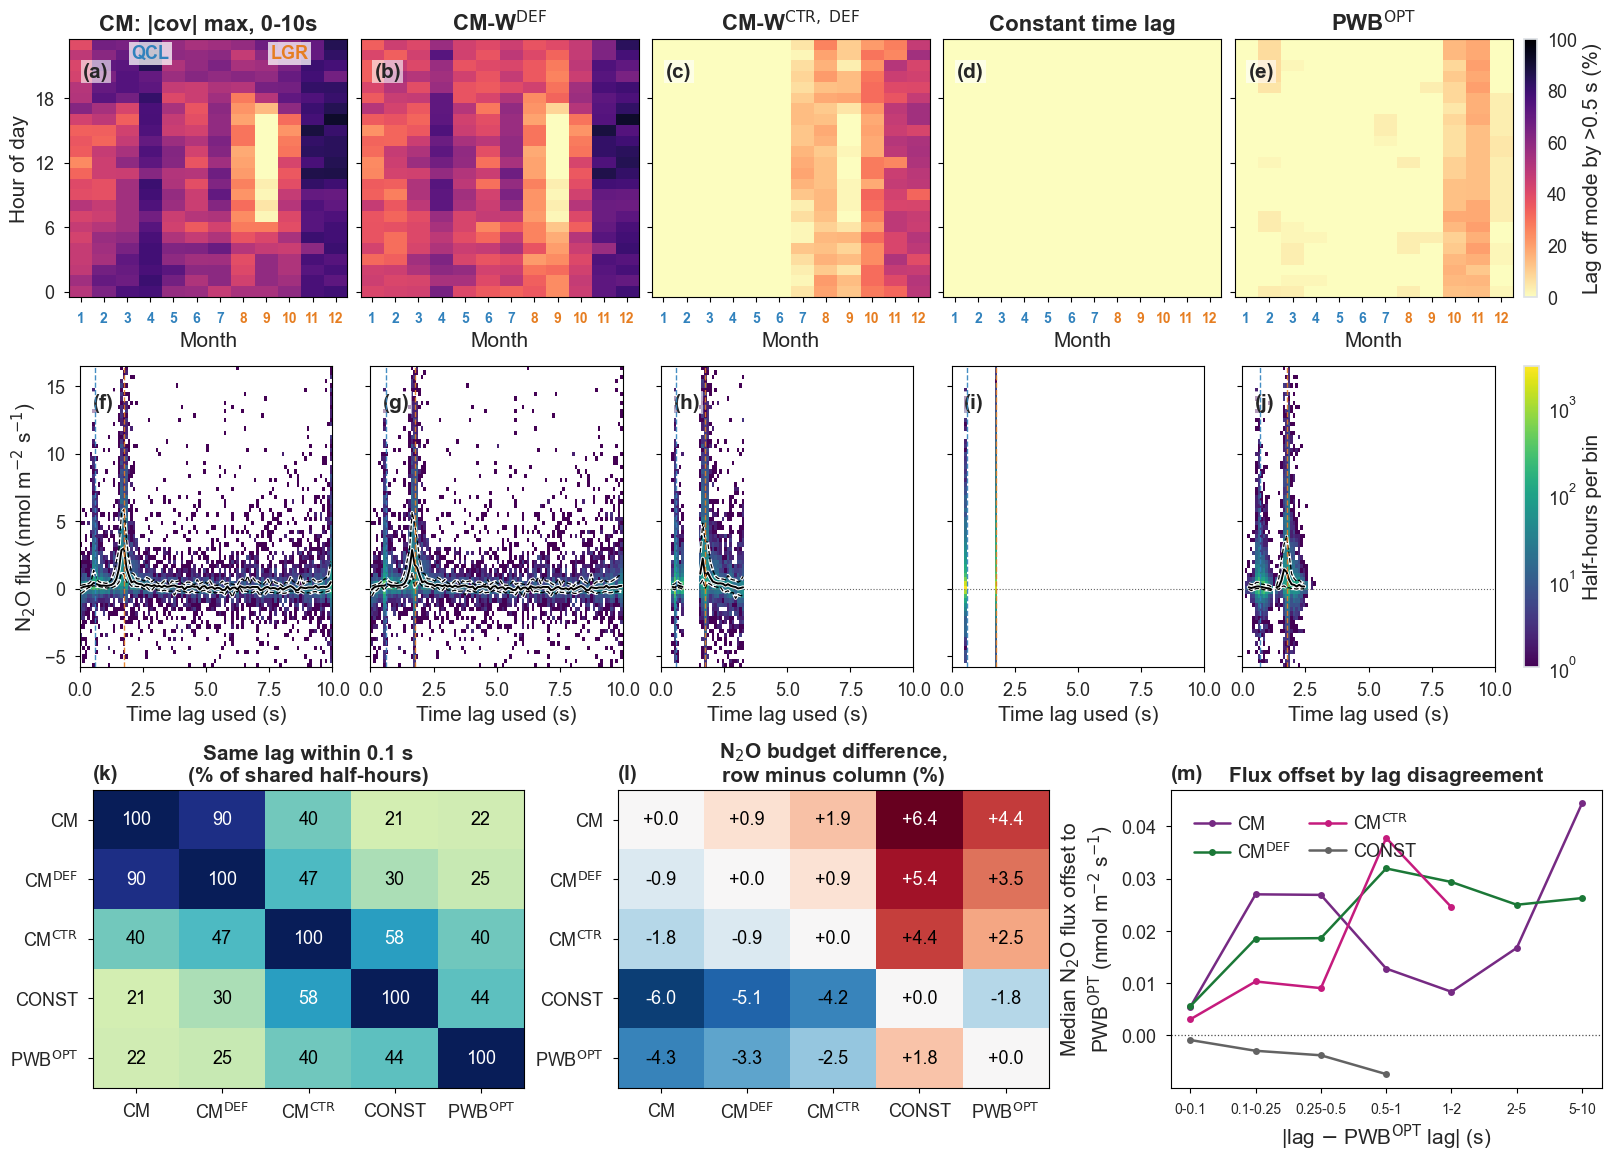

Saved ..\figures\suppl_lagdiag_ch4.png


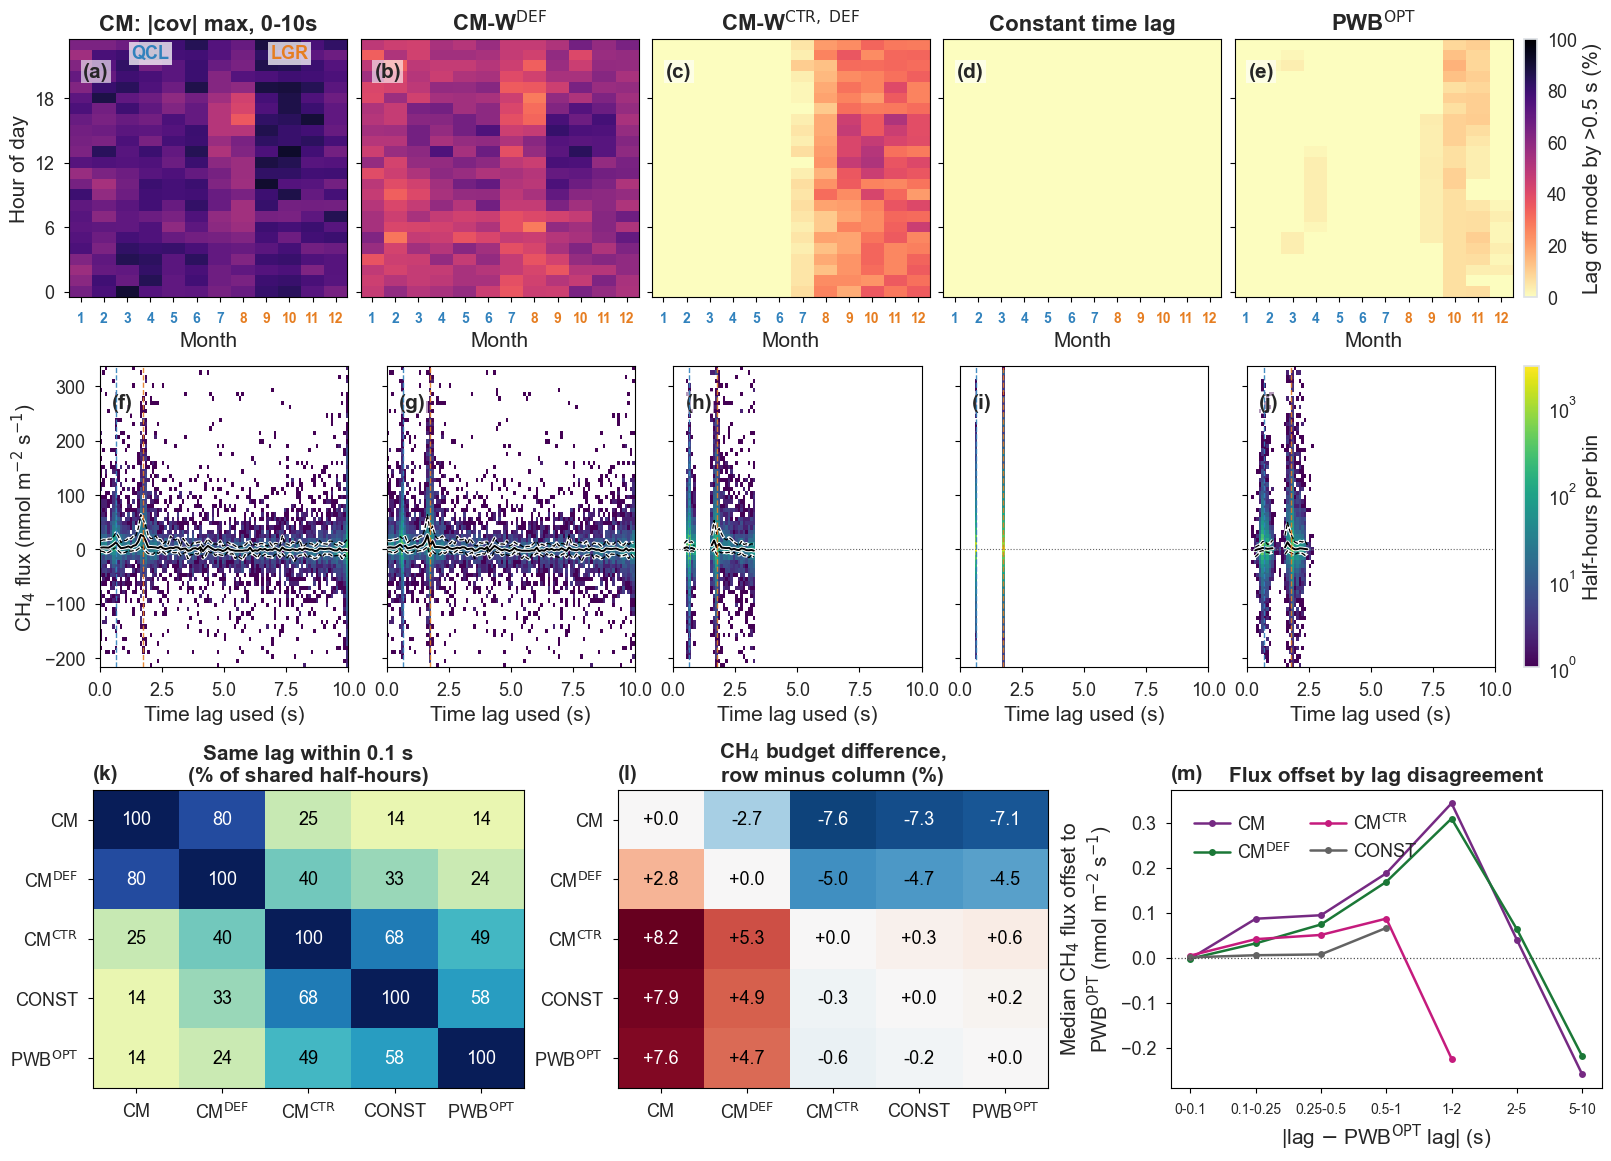

In [4]:
def style_axes(ax):
    """Black spines, short outward major/minor ticks, no grid."""
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)
    ax.tick_params(which="major", length=3.5, width=0.8, direction="out", color="black")
    ax.tick_params(which="minor", length=2.0, width=0.6, direction="out", color="black")


def panel_letter(ax, text):
    """Bold panel letter in the top-left corner, over a faint white patch."""
    ax.text(0.05, 0.91, f"({text})", transform=ax.transAxes, va="top", ha="left",
            fontsize=FS_PANEL, fontweight="bold",
            bbox=dict(boxstyle="square,pad=0.1", fc="white", ec="none", alpha=0.6))


def mode_on_grid(values):
    """Modal lag snapped to the BIN_S (0.05 s) tlag raster: the peak 0.05 s bin of
    the non-fringe lags (so the 0 s / 10 s rails cannot be the mode), e.g. 0.65 s.
    Matches how EddyPro reports the lag. Returns None if no non-fringe lag exists."""
    s = pd.Series(values).dropna()
    s = s[(s > LO_EDGE) & (s < HI_EDGE)]
    if s.empty:
        return None
    lo_k = int(np.floor(s.min() / BIN_S))
    hi_k = int(np.ceil(s.max() / BIN_S))
    edges = (np.arange(lo_k, hi_k + 2) - 0.5) * BIN_S  # bins centred on k * BIN_S
    counts, _ = np.histogram(s, bins=edges)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return float(centers[int(np.argmax(counts))])


def corner_letter(ax, text):
    """Panel letter placed above the axes, at its left edge. The bottom row is
    filled edge to edge (matrix cells, a legend), so the letter goes outside."""
    ax.text(0.0, 1.02, f"({text})", transform=ax.transAxes, ha="left", va="bottom",
            fontsize=FS_PANEL, fontweight="bold")


def pairwise(values_by_variant, func):
    """Variant by variant matrix of func(series_row, series_column), computed on the
    half-hours both variants report."""
    n = len(VARIANTS)
    out = np.full((n, n), np.nan)
    for i, vi in enumerate(VARIANTS):
        for j, vj in enumerate(VARIANTS):
            pair = pd.DataFrame({"row": values_by_variant[vi],
                                 "col": values_by_variant[vj]}).dropna()
            out[i, j] = func(pair["row"], pair["col"])
    return out


def annotate_matrix(ax, mat, fmt, title, cmap, vmin, vmax, dark_above):
    """Draw a variant by variant matrix with its values printed in the cells."""
    ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, format(mat[i, j], fmt), ha="center", va="center", fontsize=FS_ANNOT,
                    color="white" if abs(mat[i, j]) > dark_above else "black")
    ticks = [VARIANT_SHORT[v] for v in VARIANTS]
    ax.set_xticks(range(len(VARIANTS)), ticks, fontsize=FS_ANNOT)
    ax.set_yticks(range(len(VARIANTS)), ticks, fontsize=FS_ANNOT)
    ax.set_title(title, fontsize=FS_LABEL)
    style_axes(ax)


for gas in GASES:
    glabel = GAS_LABEL[gas]
    flux = {v: merged_flux[(v, gas)] for v in VARIANTS}
    lag = {v: merged_lag[(v, gas)] for v in VARIANTS}

    # Distance of each half-hour's lag from its own variant and instrument mode.
    # The mode is the raster-snapped peak of the non-fringe lags (mode_on_grid), so
    # the 0 s / 10 s rails of the open search window cannot serve as the reference.
    modes = {(v, a): mode_on_grid(lag_used[(a, v, gas)])
             for v in VARIANTS for a in ANALYZERS}
    off_mode = {}
    for v in VARIANTS:
        dev = pd.Series(np.nan, index=merged.index)
        for a in ANALYZERS:
            if modes[(v, a)] is not None:
                dev[is_analyzer[a]] = (lag[v][is_analyzer[a]] - modes[(v, a)]).abs()
        off_mode[v] = dev

    # Flux axis of the density row: robust range over all variants of this gas.
    all_flux = np.concatenate([flux[v].to_numpy() for v in VARIANTS])
    f_lo, f_hi = np.nanpercentile(all_flux, PCTL)
    f_pad = 0.05 * (f_hi - f_lo)
    flux_lim = (f_lo - f_pad, f_hi + f_pad)
    flux_edges = np.linspace(*flux_lim, 71)

    fig = plt.figure(figsize=FIGSIZE_DIAG, constrained_layout=True)
    # One subfigure per row, so each row keeps its own layout and colorbar.
    sf_top, sf_mid, sf_bot = fig.subfigures(nrows=3, height_ratios=[1.0, 1.05, 1.2])
    gs_top, gs_mid = sf_top.add_gridspec(1, 5), sf_mid.add_gridspec(1, 5)
    gs_bot = sf_bot.add_gridspec(1, 3)

    # Row 1: how often the lag left its own mode, by month and hour of day.
    hm_axes = []
    for ci, v in enumerate(VARIANTS):
        ax = sf_top.add_subplot(gs_top[0, ci])
        hm_axes.append(ax)
        d = pd.DataFrame({"month": month, "hour": hour,
                          "off": (off_mode[v] > OFF_MODE_S).astype(float).to_numpy()})
        d = d[off_mode[v].notna().to_numpy()]
        table = d.pivot_table(index="hour", columns="month", values="off", aggfunc="mean")
        grid = np.full((24, 12), np.nan)
        for mo in table.columns:
            grid[table.index.to_numpy(), int(mo) - 1] = table[mo].to_numpy() * 100
        im_off = ax.pcolormesh(np.arange(0.5, 13.5), np.arange(-0.5, 24.5), grid,
                               cmap="magma_r", vmin=0, vmax=100, shading="auto")
        style_axes(ax)
        panel_letter(ax, LETTERS[ci])
        ax.set_title(VARIANT_NAMES[v], fontweight="bold", fontsize=FS_TITLE)
        ax.set_xticks(range(1, 13), range(1, 13), fontsize=FS_DENSE)
        for label, mo in zip(ax.get_xticklabels(), range(1, 13)):
            if dominant_analyzer[mo]:
                label.set_color(INSTRUMENT_COLORS[dominant_analyzer[mo]])
                label.set_fontweight("bold")
        ax.set_yticks([0, 6, 12, 18])
        ax.set_xlim(0.5, 12.5)
        ax.set_ylim(-0.5, 23.5)
        ax.set_xlabel("Month")
        if ci == 0:
            ax.set_ylabel("Hour of day")
            # Name each campaign where it sits on the month axis; the month tick
            # labels carry the same instrument colors in every panel of this row.
            for a, x_center in zip(ANALYZERS, campaign_center):
                ax.text(x_center, 23.0, a, color=INSTRUMENT_COLORS[a], fontsize=FS_ANNOT,
                        fontweight="bold", ha="center", va="top",
                        bbox=dict(boxstyle="square,pad=0.15", fc="white", ec="none",
                                  alpha=0.75))
        else:
            ax.tick_params(labelleft=False)
    cb_off = sf_top.colorbar(im_off, ax=hm_axes, location="right", pad=0.008, fraction=0.02)
    cb_off.set_label(f"Lag off mode by >{OFF_MODE_S:g} s (%)", fontsize=FS_LABEL)

    # Row 2: joint density of the lag that was used and the flux it produced.
    density_axes = []
    for ci, v in enumerate(VARIANTS):
        ax = sf_mid.add_subplot(gs_mid[0, ci])
        density_axes.append(ax)
        d = pd.DataFrame({"lag": lag[v], "flux": flux[v]}).dropna()
        counts, _, _ = np.histogram2d(d["lag"], d["flux"], bins=[LAG_EDGES, flux_edges])
        im_den = ax.pcolormesh(LAG_EDGES, flux_edges, np.where(counts == 0, np.nan, counts).T,
                               cmap="viridis", shading="flat",
                               norm=LogNorm(vmin=1, vmax=COUNT_VMAX))
        # Median and quartiles of the flux per lag bin. Thin bins are dropped and
        # the lines break there, so the single-valued variants get no line drawn
        # across lag space they never visit.
        binned = d.groupby(pd.cut(d["lag"], LAG_EDGES, labels=LAG_CENTERS),
                           observed=True)["flux"].agg(
            n="size", med="median", q1=lambda s: s.quantile(0.25),
            q3=lambda s: s.quantile(0.75))
        binned = binned.where(binned["n"] >= MIN_N).reindex(LAG_CENTERS)
        for stat, lw, ls in (("q1", 0.9, "--"), ("q3", 0.9, "--"), ("med", 1.4, "-")):
            ax.plot(LAG_CENTERS, binned[stat], color="white", lw=lw + 1.4, ls=ls, zorder=4)
            ax.plot(LAG_CENTERS, binned[stat], color="black", lw=lw, ls=ls, zorder=5)
        for a in ANALYZERS:
            if modes[(v, a)] is not None:
                ax.axvline(modes[(v, a)], color=INSTRUMENT_COLORS[a], lw=1.0, ls="--",
                           alpha=0.9, zorder=6)
        ax.axhline(0, color="0.4", lw=0.8, ls=":", zorder=3)
        ax.set_xlim(*SEARCH_WINDOW)
        ax.set_ylim(*flux_lim)
        style_axes(ax)
        panel_letter(ax, LETTERS[len(VARIANTS) + ci])
        ax.set_xlabel("Time lag used (s)")
        if ci == 0:
            ax.set_ylabel(f"{glabel} flux (nmol m$^{{-2}}$ s$^{{-1}}$)")
        else:
            ax.tick_params(labelleft=False)
    cb_den = sf_mid.colorbar(im_den, ax=density_axes, location="right", pad=0.008,
                             fraction=0.02)
    cb_den.set_label("Half-hours per bin", fontsize=FS_LABEL)

    # Row 3, left: how often two variants pick the same lag.
    same_lag = pairwise(lag, lambda r, c: float((r - c).abs().le(SAME_LAG_S).mean() * 100))
    annotate_matrix(sf_bot.add_subplot(gs_bot[0, 0]), same_lag, ".0f",
                    f"Same lag within {SAME_LAG_S:g} s\n(% of shared half-hours)",
                    "YlGnBu", 0, 100, dark_above=55)
    corner_letter(sf_bot.axes[-1], LETTERS[2 * len(VARIANTS)])

    # Row 3, middle: what that costs in the summed flux, over the shared half-hours.
    budget = pairwise(flux, lambda r, c: float((r.sum() - c.sum()) / abs(c.sum()) * 100))
    b_max = float(np.nanmax(np.abs(budget))) or 1.0
    annotate_matrix(sf_bot.add_subplot(gs_bot[0, 1]), budget, "+.1f",
                    f"{glabel} budget difference,\nrow minus column (%)",
                    "RdBu_r", -b_max, b_max, dark_above=0.7 * b_max)
    corner_letter(sf_bot.axes[-1], LETTERS[2 * len(VARIANTS) + 1])

    # Row 3, right: the same comparison resolved by how far the variant's lag sits
    # from the PWB_OPT lag in that half-hour.
    ax = sf_bot.add_subplot(gs_bot[0, 2])
    x_pos = np.arange(len(DEV_EDGES) - 1)
    for v in VARIANTS:
        if v == PWB_VARIANT:
            continue
        d = pd.DataFrame({"dev": (lag[v] - lag[PWB_VARIANT]).abs(),
                          "offset": flux[v] - flux[PWB_VARIANT]}).dropna()
        binned = d.groupby(pd.cut(d["dev"], DEV_EDGES, labels=x_pos, include_lowest=True),
                           observed=True)["offset"].agg(n="size", med="median")
        binned = binned[binned["n"] >= MIN_N]
        ax.plot(binned.index.astype(float), binned["med"], "-o", ms=5, lw=1.8,
                color=VARIANT_COLORS[v], label=VARIANT_SHORT[v])
    ax.axhline(0, color="0.3", lw=0.9, ls=":")
    ax.set_xticks(x_pos, [f"{DEV_EDGES[i]:g}-{DEV_EDGES[i + 1]:g}" for i in x_pos],
                  fontsize=FS_DENSE)
    ax.set_xlabel(r"|lag $-$ PWB$^{\mathrm{OPT}}$ lag| (s)")
    ax.set_ylabel(f"Median {glabel} flux offset to\n"
                  f"PWB$^{{\\mathrm{{OPT}}}}$ (nmol m$^{{-2}}$ s$^{{-1}}$)")
    ax.set_title("Flux offset by lag disagreement", fontsize=FS_LABEL)
    ax.legend(ncols=2, loc="upper left", bbox_to_anchor=(0.02, 0.97),
              framealpha=0.9, handletextpad=0.4, borderpad=0.3, columnspacing=1.0)
    style_axes(ax)
    corner_letter(ax, LETTERS[2 * len(VARIANTS) + 2])

    out = FIGDIR / f"suppl_lagdiag_{gas.lower()}.png"
    fig.savefig(out, dpi=DPI, bbox_inches="tight")
    print(f"Saved {out}")
    plt.show()


**Figure.** Level-1 (pre-quality-control) time-lag diagnostics, one figure per gas
(N₂O first, then CH₄). Top row: share of half-hours whose lag left its own modal
lag by more than 0.5 s, by month and hour of day, one panel per variant. Middle row:
joint histogram of the half-hourly flux and the lag it was computed with, with the
median and quartiles per lag bin and the two instruments' modal lags (dashed).
Bottom row: how often two variants agree on the lag (k), what that means for the
summed flux over their shared half-hours (l), and the median flux offset to
PWB$_{OPT}$ against the distance between the two lags (m). Saved as
`figures/suppl_lagdiag_{gas}.png`.


## Runtime

In [5]:
NB_END = datetime.now()
print(f"Start:    {NB_START:%Y-%m-%d %H:%M:%S}")
print(f"End:      {NB_END:%Y-%m-%d %H:%M:%S}")
print(f"Runtime:  {NB_END - NB_START}")


Start:    2026-07-24 15:01:51
End:      2026-07-24 15:02:00
Runtime:  0:00:08.944821
